In [ ]:
# !pip install scikit-learn numpy pandas 
# !pip install matplotlib

In [65]:
from sklearn.linear_model import LogisticRegression
from  sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import *


In [28]:
data = load_breast_cancer()

In [31]:
X = data.data
y= data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [74]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [40]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[39,  4],
       [ 1, 70]])

In [54]:
tn, fp, fn, tp = cm.ravel()
tp, fp, fn, tn

(np.int64(70), np.int64(4), np.int64(1), np.int64(39))

In [46]:
def calculate_metrics(tp, fp, fn, tn):
    n = tp+fp+fn+tn
    acc = (tp+tn)/(n)
    pre = tp/(tp+fp)
    rec = tp/(tp+fn)
    f1 = 2*pre*rec/(pre+rec)
    return acc, pre, rec, f1

In [49]:
def calculate_metrics_built_in(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, pre, rec, f1    


In [55]:
custom = calculate_metrics(tp, fp, fn, tn)
built_in = calculate_metrics_built_in(y_test, y_pred)

In [56]:
metrics = ["acc", "pre", "rec", "f1"  ]
print(metrics)
print(custom)
print(built_in)

['acc', 'pre', 'rec', 'f1']
(np.float64(0.956140350877193), np.float64(0.9459459459459459), np.float64(0.9859154929577465), np.float64(0.9655172413793103))
(0.956140350877193, 0.9459459459459459, 0.9859154929577465, 0.9655172413793104)


In [67]:

rand1 = np.random.rand(y_test.size)

In [68]:
import matplotlib.pyplot as plt

/var/folders/_r/_zh67rmx3t9g6lrcny8nn72h0000gn/T/ipykernel_70773/2896301571.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


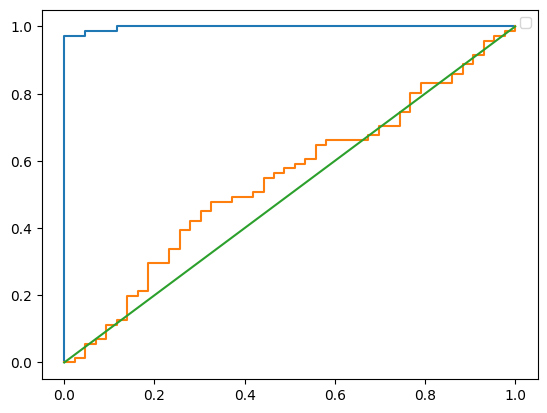

In [ ]:
fpr, tpr, _=roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)

fpr, tpr, _ =roc_curve(y_test, rand1)

plt.plot(fpr, tpr)

plt.plot([1,0],[1,0])


[[39  4]
 [ 1 70]]
70 4 1 39
       acc       pre       rec        f1       spe    npv       mcc
0  0.95614  0.945946  0.985915  0.965517  0.906977  0.975  0.906811
1  0.95614  0.945946  0.985915  0.965517  0.906977  0.975  0.906811


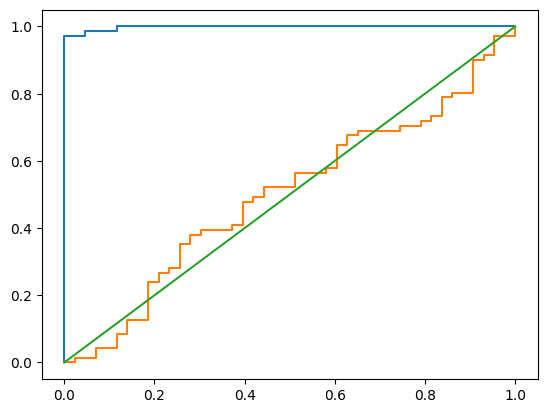

In [105]:
from sklearn.linear_model import LogisticRegression
from  sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import pandas as pd

data = load_breast_cancer()

X = data.data
y= data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test,y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
print(tp, fp, fn, tn)


def calculate_metrics(tp, fp, fn, tn):
    n = tp+fp+fn+tn
    acc = (tp+tn)/(n)
    pre = tp/(tp+fp)
    rec = tp/(tp+fn)
    f1 = 2*pre*rec/(pre+rec)
    spe = tn/(tn+fp)
    npv = tn/(tn+fn)
    mcc = (tn*tp - fn*fp)/np.sqrt((tn+fp)*(tn+fn)*(tp+fp)*(tp+fn))
    return acc, pre, rec, f1,spe, npv, mcc


def calculate_metrics_built_in(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    spe = tn/(tn+fp)
    npv = tn/(tn+fn)
    mcc = matthews_corrcoef(y_true, y_pred)
    return acc, pre, rec, f1,spe, npv, mcc


custom = calculate_metrics(tp, fp, fn, tn)
built_in = calculate_metrics_built_in(y_test, y_pred)


metrics = ["acc", "pre", "rec", "f1", "spe",  "npv", "mcc" ]
metrics_df = pd.DataFrame([custom,built_in],columns=metrics)
print(metrics_df.head())
rand1 = np.random.rand(y_test.size)

import matplotlib.pyplot as plt

fpr, tpr, _=roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)

fpr, tpr, _ =roc_curve(y_test, rand1)

plt.plot(fpr, tpr)

plt.plot([1,0],[1,0])





In [89]:
import sklearn.metrics as m
dir(m)

['ConfusionMatrixDisplay',
 'DetCurveDisplay',
 'DistanceMetric',
 'PrecisionRecallDisplay',
 'PredictionErrorDisplay',
 'RocCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_classification',
 '_dist_metrics',
 '_pairwise_distances_reduction',
 '_pairwise_fast',
 '_plot',
 '_ranking',
 '_regression',
 '_scorer',
 'accuracy_score',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'auc',
 'average_precision_score',
 'balanced_accuracy_score',
 'brier_score_loss',
 'calinski_harabasz_score',
 'check_scoring',
 'class_likelihood_ratios',
 'classification_report',
 'cluster',
 'cohen_kappa_score',
 'completeness_score',
 'confusion_matrix',
 'confusion_matrix_at_thresholds',
 'consensus_score',
 'coverage_error',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'd2_pinball_score',
 'd2_tweedie_score',
 'davies_bouldin_score',
 'dcg_score',
 'det_cu

array([[0, 1],
       [0, 0]])

(np.float64(0.956140350877193), np.float64(0.9459459459459459), np.float64(0.9859154929577465), np.float64(0.9069767441860465), np.float64(0.9655172413793103), np.float64(0.975), np.float64(0.9068106119605033))
(0.956140350877193, 0.9459459459459459, 0.9859154929577465, np.float64(0.9069767441860465), 0.9655172413793104, np.float64(0.975), 0.9068106119605033)


/Users/prince-khatri/Desktop/Sem-6/ml-lab/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


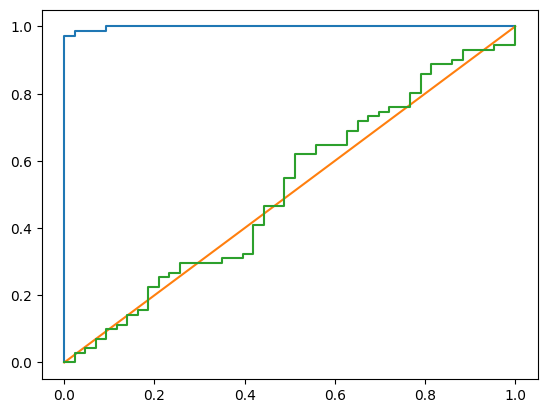

In [21]:
# Using any dataset, calculate TP, TN, FP ,FN and different metrics (Accuracy, Precision, Recall(Sensitivity), 
# F1-Score, MCC, Specificity, Negative Predictive Value) by defining your own functions. Compare your values 
# with scikit-learn's library functions. Get the result of Confusion Matrix using sklearn. Using sklearn, 
# plot the ROC & AUC Curves for your test data and random probabilities. 
# Using sklearn, calculate the AUC of your test data and of random probabilities. Interpret the results. 
# Write the inference/analysis of each output.

from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
data = load_breast_cancer()
X=data.data
y=data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression()

model.fit(X_train,y_train)

outcome = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, outcome)
tn, fp, fn, tp = cm.ravel()

def custom(tp,fp,fn,tn):
    acc = (tp+tn)/(tp+fp+fn+tn)
    pre = tp/(tp+fp)
    rec = tp/(tp+fn)
    spe = tn/(tn+fp)
    f1 = 2*pre*rec/(pre+rec)
    npv = tn/(tn+fn)
    mcc = ((tp*tn)-(fp*fn))/np.sqrt((tn+fn)*(tn+fp)*(tp+fn)*(tp+fp))
    return acc, pre, rec, spe, f1, npv, mcc

def built_in(y_true,y_pred):
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    spe = tn/(tn+fp)
    f1 = f1_score(y_true,y_pred)
    npv = tn/(tn+fn)
    mcc = matthews_corrcoef(y_true,y_pred)
    return acc, pre, rec, spe, f1, npv, mcc

print(custom(tp,fp,fn,tn))
print(built_in(y_test,outcome))

random = np.random.rand(len(y_test))

import matplotlib.pyplot as plt

m_plot = roc_curve(y_test,y_proba)
r_plot = roc_curve(y_test,random)

m_auc = roc_auc_score(y_test,y_proba)
r_auc = roc_auc_score(y_test,random)

plt.plot(m_plot[0],m_plot[1])
plt.plot([0,1],[0,1])
plt.plot(r_plot[0],r_plot[1])


[[39  4]
 [ 1 70]]
<built-in method ravel of numpy.ndarray object at 0x1195f2070>
       acc       pre       rec       spe        f1    npv       mcc
0  0.95614  0.945946  0.985915  0.906977  0.965517  0.975  0.906811
1  0.95614  0.945946  0.985915  0.906977  0.965517  0.975  0.906811
0.9983622666229939 0.5119554536521453


/Users/prince-khatri/Desktop/Sem-6/ml-lab/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


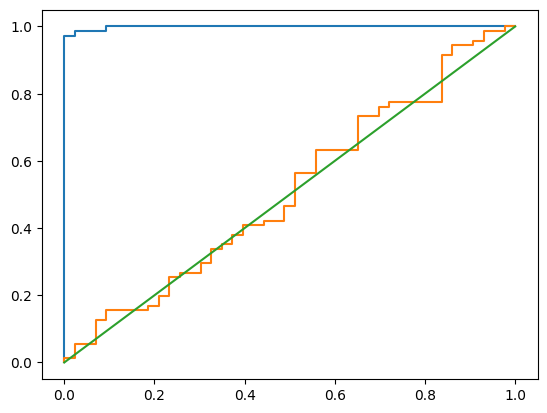

In [27]:

from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = load_breast_cancer()
X=data.data
y=data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(cm)
print(cm.ravel)
def custom(tp,fp,fn,tn):
    acc = (tp+tn)/(tp+fp+fn+tn)
    pre = tp/(tp+fp)
    rec = tp/(tp+fn)
    spe = tn/(tn+fp)
    f1 = 2*pre*rec/(pre+rec)
    npv = tn/(tn+fn)
    mcc = ((tp*tn)-(fp*fn))/np.sqrt((tp+fp)*(tn+fp)*(tp+fn)*(tn+fn))
    return acc, pre, rec, spe, f1, npv, mcc

def built_in(y_true,y_pred):
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    spe = tn/(tn+fp)
    f1 = f1_score(y_true,y_pred)
    npv = tn/(tn+fn)
    mcc = matthews_corrcoef(y_true,y_pred)

    return acc, pre, rec, spe, f1, npv, mcc

col =[ "acc", "pre", "rec", "spe", "f1", "npv", "mcc"]

metrics = pd.DataFrame([ custom(tp,fp,fn,tn),built_in(y_test,y_pred)], columns=col)

print(metrics.head())
rand = np.random.rand(len(y_test))
fpr,tpr,_ = roc_curve(y_test, y_proba)
plt.plot(fpr,tpr)
fpr,tpr,_ = roc_curve(y_test, rand)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])

roc_m = roc_auc_score(y_test, y_proba)
roc_r = roc_auc_score(y_test, rand)
print(roc_m, roc_r)


